1. SETUP & DATA LOADING

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from google.colab import drive
drive.mount('/content/drive')
# Load master panel
df = pd.read_csv("/content/drive/MyDrive/DSO 459/Final Project: Observing AI in S&P 500/459 Earnings Calls Transcripts/master_panel.csv")

# Count transcripts per company
transcript_counts = df.groupby("ticker")["filename"].count().reset_index()
transcript_counts.columns = ["ticker", "transcript_count"]
print("Transcripts per company:")
print(transcript_counts.sort_values("transcript_count", ascending=False).to_string())

# Filter to companies with 10+ transcripts
qualified = transcript_counts[transcript_counts["transcript_count"] >= 10]["ticker"].tolist()
print(f"\nCompanies with 10+ transcripts: {len(qualified)}")
print(qualified)

df_filtered = df[df["ticker"].isin(qualified)].copy()
print(f"\nFiltered dataset: {len(df_filtered)} rows, {df_filtered['ticker'].nunique()} companies")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Transcripts per company:
   ticker  transcript_count
36    WBD                16
12    DIS                16
3    AVGO                15
30      T                14
4     AXP                14
1    AMAT                14
19    LMT                14
34      V                13
18    JPM                13
31   TMUS                13
21     MA                13
11     DE                13
5      BA                12
7       C                12
8     CAT                12
24   MSFT                12
35     VZ                12
23     MS                11
14     GE                11
27   NVDA                 9
33    UNP                 9
20   LRCX                 9
13     EA                 9
25     MU                 8
6     BAC                 7
2     AMD                 7
26   NFLX                 6
9   CMCSA                 6
15  GOOGL                 6
17    

2. VARIABLE PREPARATION

*   Log_rpe
*   Log_assets
*   year dummies
*   lagged_log_rpe
*   post_chatgpt
*   ai_mention
*   sector mapping
*   quarter_year
*   first_ai_mention variables
*   ai_adoption_stage
*   lagged_ai_mention


In [ ]:
# Prepare regression variables
df_filtered = df_filtered.copy()

# Log transform RPE, which is standard to handle skewness
df_filtered["log_rpe"] = np.log(df_filtered["Revenue per Employee"])

# Log transform assets as size control
df_filtered["log_assets"] = np.log(df_filtered["Assets"])

# Create year dummies for time fixed effects
df_filtered["year"] = df_filtered["year"].astype(int)

# Sort by company and year for lag calculation
df_filtered = df_filtered.sort_values(["ticker", "year", "quarter"])

# Create lagged RPE
df_filtered["lagged_log_rpe"] = df_filtered.groupby("ticker")["log_rpe"].shift(1)

# Create post-ChatGPT indicator (ChatGPT launched November 2022 so Q1 2023 and onward)
df_filtered["post_chatgpt"] = ((df_filtered["year"] > 2022) |
                                ((df_filtered["year"] == 2022) &
                                 (df_filtered["quarter"] == "Q4"))).astype(int)

# Create binary AI mention indicator
df_filtered["ai_mention"] = (df_filtered["total_ai_mentions"] > 0).astype(int)

# Lagged AI mention (1 quarter lag)
df_filtered["lagged_ai_mention"] = df_filtered.groupby("ticker")["ai_mention"].shift(1)

print(f"Dataset shape: {df_filtered.shape}")
print(f"\nPost-ChatGPT distribution:")
print(df_filtered["post_chatgpt"].value_counts())
print(f"\nAI mention distribution:")
print(df_filtered["ai_mention"].value_counts())
print(f"\nSample:")
display(df_filtered[["ticker", "quarter", "year", "normalized_score", "total_ai_mentions", "log_rpe", "post_chatgpt"]].head(10))

Dataset shape: (250, 36)

Post-ChatGPT distribution:
post_chatgpt
1    189
0     61
Name: count, dtype: int64

AI mention distribution:
ai_mention
1    142
0    108
Name: count, dtype: int64

Sample:


,ticker,quarter,year,normalized_score,total_ai_mentions,log_rpe,post_chatgpt
129,AMAT,Q1,2022,0.000293,3,13.568796,0
173,AMAT,Q2,2022,0.000000,0,13.568796,0
171,AMAT,Q3,2022,0.000000,0,13.568796,0
161,AMAT,Q4,2022,0.000000,0,13.568796,1
125,AMAT,Q1,2023,0.000209,2,13.566936,1
149,AMAT,Q2,2023,0.000000,0,13.566936,1
150,AMAT,Q3,2023,0.001676,16,13.566936,1
147,AMAT,Q4,2023,0.001146,11,13.566936,1
121,AMAT,Q1,2024,0.001342,13,13.542694,1
148,AMAT,Q2,2024,0.001823,17,13.542694,1


In [ ]:
# Sector mapping
sector_map = {
    "AMAT": "IT", "AVGO": "IT", "MSFT": "IT",
    "JPM": "Financials", "MA": "Financials", "MS": "Financials",
    "AXP": "Financials", "C": "Financials", "V": "Financials",
    "WFC": "Financials",
    "BA": "Industrials", "CAT": "Industrials", "DE": "Industrials",
    "GE": "Industrials", "LMT": "Industrials", "UNP": "Industrials",
    "T": "Comm Services", "TMUS": "Comm Services",
    "DIS": "Comm Services", "VZ": "Comm Services", "WBD": "Comm Services"
}

df_filtered["sector"] = df_filtered["ticker"].map(sector_map)
print(df_filtered.groupby("sector")["ticker"].nunique())

sector
Comm Services    5
Financials       6
IT               3
Industrials      5
Name: ticker, dtype: int64


In [ ]:
# Quarter-year label for time axis
df_filtered["quarter_year"] = df_filtered["quarter"] + " " + df_filtered["year"].astype(str)

In [ ]:
# First AI mention per company
first_ai_mention = df_filtered[df_filtered["ai_mention"] == 1].groupby("ticker")["quarter_year"].first().reset_index()
first_ai_mention.columns = ["ticker", "first_ai_quarter"]
print("First AI mention per company:")
print(first_ai_mention)

# Merge back
df_filtered = df_filtered.merge(first_ai_mention, on="ticker", how="left")

# Binary: is this the first quarter this company mentioned AI?
df_filtered["first_ai_mention"] = (df_filtered["quarter_year"] == df_filtered["first_ai_quarter"]).astype(int)

# Previously mentioned AI
df_filtered["prev_mentioned_ai"] = df_filtered.groupby("ticker")["ai_mention"].cumsum().shift(1)
df_filtered["prev_mentioned_ai"] = (df_filtered["prev_mentioned_ai"] > 0).fillna(0).astype(int)

print(f"\nFirst AI mention distribution:")
print(df_filtered["first_ai_mention"].value_counts())
print(f"\nPreviously mentioned AI distribution:")
print(df_filtered["prev_mentioned_ai"].value_counts())

First AI mention per company:
   ticker first_ai_quarter
0    AMAT          Q1 2022
1    AVGO          Q1 2022
2     AXP          Q4 2021
3       C          Q4 2021
4     CAT          Q4 2022
5      DE          Q1 2022
6     DIS          Q2 2023
7      GE          Q4 2021
8     JPM          Q4 2021
9     LMT          Q1 2022
10     MA          Q1 2022
11     MS          Q3 2022
12   MSFT          Q2 2022
13      T          Q1 2023
14   TMUS          Q4 2021
15      V          Q1 2022
16     VZ          Q1 2023
17    WBD          Q1 2024

First AI mention distribution:
first_ai_mention
0    232
1     18
Name: count, dtype: int64

Previously mentioned AI distribution:
prev_mentioned_ai
1    207
0     43
Name: count, dtype: int64


In [ ]:
# AI Adoption Stage
# Stage 0 = before first AI mention (company has never mentioned AI)
# Stage 1 = the quarter of first AI mention
# Stage 2 = after first AI mention (company is an established AI discloser)

# Cumulative sum of ai_mention per company
df_filtered["cumsum_ai"] = df_filtered.groupby("ticker")["ai_mention"].cumsum()

# Create the three states — default is 0 (before)
df_filtered["ai_adoption_stage"] = 0

# After first mention (cumsum > 1 means mentioned at least once before)
df_filtered.loc[df_filtered["cumsum_ai"] > 1, "ai_adoption_stage"] = 2

# First mention quarter (cumsum == 1 and ai_mention == 1)
df_filtered.loc[
    (df_filtered["cumsum_ai"] == 1) &
    (df_filtered["ai_mention"] == 1),
    "ai_adoption_stage"
] = 1

print("AI adoption stage distribution:")
print(df_filtered["ai_adoption_stage"].value_counts().sort_index())
print("\nStage 0 = before first mention")
print("Stage 1 = first mention quarter")
print("Stage 2 = after first mention")

AI adoption stage distribution:
ai_adoption_stage
0     68
1     18
2    164
Name: count, dtype: int64

Stage 0 = before first mention
Stage 1 = first mention quarter
Stage 2 = after first mention


3. REGRESSION MODELS

Model 1: Baseline OLS

In [ ]:
# Create baseline OLS regression

model_ols = smf.ols(
    formula='log_rpe ~ ai_mention + log_assets + C(year)',
    data=df_filtered
).fit()

print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                log_rpe   R-squared:                       0.122
Model:                            OLS   Adj. R-squared:                  0.101
Method:                 Least Squares   F-statistic:                     5.653
Date:                Thu, 07 May 2026   Prob (F-statistic):           1.63e-05
Time:                        18:57:58   Log-Likelihood:                -113.04
No. Observations:                 250   AIC:                             240.1
Df Residuals:                     243   BIC:                             264.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          13.0279      0.524     

Model 2: Fixed Effects (FE)

In [ ]:
# Fixed Effects model with company dummies

model_fe = smf.mixedlm(
    formula='log_rpe ~ ai_mention + log_assets + C(year)',
    data=df_filtered,
    groups=df_filtered['ticker']
).fit()

print(model_fe.summary())

          Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  log_rpe 
No. Observations:   250      Method:              REML    
No. Groups:         19       Scale:               0.0102  
Min. group size:    11       Log-Likelihood:      150.4219
Max. group size:    16       Converged:           Yes     
Mean group size:    13.2                                  
----------------------------------------------------------
                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept       17.004    1.081 15.736 0.000 14.886 19.121
C(year)[T.2022]  0.052    0.034  1.561 0.119 -0.013  0.118
C(year)[T.2023]  0.194    0.034  5.666 0.000  0.127  0.261
C(year)[T.2024]  0.231    0.034  6.760 0.000  0.164  0.298
C(year)[T.2025]  0.307    0.036  8.555 0.000  0.237  0.377
ai_mention      -0.034    0.016 -2.106 0.035 -0.066 -0.002
log_assets      -0.137    0.041 -3.303 0.001 -0.218 -0.056
Group Va

Model 3: FE + Lagged RPE

In [ ]:
# Add lagged RPE
model_lag = smf.mixedlm(
    formula='log_rpe ~ ai_mention + log_assets + C(year) + lagged_log_rpe',
    data=df_filtered.dropna(subset=['lagged_log_rpe']),
    groups=df_filtered.dropna(subset=['lagged_log_rpe'])['ticker']
).fit()

print(model_lag.summary())

          Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  log_rpe 
No. Observations:   231      Method:              REML    
No. Groups:         19       Scale:               0.0039  
Min. group size:    10       Log-Likelihood:      262.7952
Max. group size:    15       Converged:           Yes     
Mean group size:    12.2                                  
----------------------------------------------------------
                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept        2.848    1.064  2.676 0.007  0.762  4.935
C(year)[T.2023]  0.071    0.013  5.349 0.000  0.045  0.097
C(year)[T.2024]  0.041    0.016  2.615 0.009  0.010  0.072
C(year)[T.2025]  0.069    0.019  3.613 0.000  0.032  0.106
ai_mention      -0.009    0.011 -0.786 0.432 -0.030  0.013
log_assets       0.006    0.017  0.388 0.698 -0.026  0.039
lagged_log_rpe   0.777    0.060 12.937 0.000  0.659  0.894
Group Va

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Model 4: FE + Lagged AI Mention

In [ ]:
# Run fixed effect model with lagged score
model_lagged_score = smf.mixedlm(
    formula='log_rpe ~ lagged_ai_mention + log_assets + C(year)',
    data=df_filtered.dropna(subset=['lagged_ai_mention']),
    groups=df_filtered.dropna(subset=['lagged_ai_mention'])['ticker']
).fit()

print("FE MODEL WITH LAGGED AI SCORE")
print(model_lagged_score.summary())

FE MODEL WITH LAGGED AI SCORE
           Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   log_rpe 
No. Observations:   231       Method:               REML    
No. Groups:         19        Scale:                0.0087  
Min. group size:    10        Log-Likelihood:       153.6002
Max. group size:    15        Converged:            Yes     
Mean group size:    12.2                                    
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept         16.726    1.198 13.958 0.000 14.377 19.075
C(year)[T.2023]    0.142    0.018  8.047 0.000  0.108  0.177
C(year)[T.2024]    0.175    0.018  9.995 0.000  0.141  0.210
C(year)[T.2025]    0.250    0.020 12.615 0.000  0.211  0.289
lagged_ai_mention -0.032    0.015 -2.103 0.035 -0.062 -0.002
log_assets        -0.124    0.046 -2.707 0.007 -0.214 -0.034
Group 

Model 5: Sector-by-Sector FE (inc IT)

In [ ]:
# Sector-by-sector fixed effects regression with ai mention
sectors = ["Comm Services", "Financials", "Industrials", "IT"]

for sector in sectors:
    sector_data = df_filtered[df_filtered["sector"] == sector].copy()
    n_companies = sector_data["ticker"].nunique()
    n_obs = len(sector_data)

    print(f"\n{'='*50}")
    print(f"SECTOR: {sector} | Companies: {n_companies} | Observations: {n_obs}")
    print(f"{'='*50}")

    if n_companies < 4:
        print("Too few companies for reliable regression — skipping")
        print(f"Companies: {sector_data['ticker'].unique()}")
        continue

    try:
        model = smf.mixedlm(
            formula='log_rpe ~ ai_mention + log_assets + C(year)',
            data=sector_data,
            groups=sector_data['ticker']
        ).fit()

        coef = model.params['ai_mention']
        pval = model.pvalues['ai_mention']
        print(f"ai_mention: coef={coef:.3f}, p={pval:.3f}")
        print(model.summary())

    except Exception as e:
        print(f"Error: {e}")


SECTOR: Comm Services | Companies: 5 | Observations: 71
ai_mention: coef=-0.016, p=0.341
          Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  log_rpe
No. Observations:    71       Method:              REML   
No. Groups:          5        Scale:               0.0026 
Min. group size:     12       Log-Likelihood:      78.1304
Max. group size:     16       Converged:           Yes    
Mean group size:     14.2                                 
----------------------------------------------------------
                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept       14.457    1.137 12.720 0.000 12.230 16.685
C(year)[T.2022] -0.076    0.035 -2.131 0.033 -0.145 -0.006
C(year)[T.2023]  0.040    0.035  1.127 0.260 -0.029  0.108
C(year)[T.2024]  0.049    0.035  1.404 0.160 -0.019  0.117
C(year)[T.2025]  0.085    0.036  2.365 0.018  0.015  0.155
ai_mention      -0.016    0.017 -0.9

In [ ]:
# IT sector, running separately despite only 3 companies
# Results should be interpreted with caution given small sample
it_data = df_filtered[df_filtered["sector"] == "IT"].copy()

print(f"\n{'='*50}")
print(f"SECTOR: IT | Companies: {it_data['ticker'].nunique()} | Observations: {len(it_data)}")
print(f"Note: Only 3 companies - interpret with caution")
print(f"{'='*50}")

model_it = smf.mixedlm(
    formula='log_rpe ~ ai_mention + log_assets + C(year)',
    data=it_data,
    groups=it_data['ticker']
).fit()

coef = model_it.params['ai_mention']
pval = model_it.pvalues['ai_mention']
print(f"ai_mention: coef={coef:.3f}, p={pval:.3f}")
print(model_it.summary())


SECTOR: IT | Companies: 3 | Observations: 41
Note: Only 3 companies - interpret with caution
ai_mention: coef=-0.072, p=0.075
          Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  log_rpe
No. Observations:    41       Method:              REML   
No. Groups:          3        Scale:               0.0048 
Min. group size:     12       Log-Likelihood:      31.9984
Max. group size:     15       Converged:           Yes    
Mean group size:     13.7                                 
----------------------------------------------------------
                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept       19.308    1.992  9.691 0.000 15.403 23.213
C(year)[T.2023]  0.093    0.035  2.648 0.008  0.024  0.161
C(year)[T.2024]  0.116    0.052  2.209 0.027  0.013  0.219
C(year)[T.2025]  0.329    0.060  5.477 0.000  0.211  0.447
ai_mention      -0.072    0.040 -1.781 0.075 -0.151  0.007

Comm Services: coef=-0.016, p=0.341 — Not significant
Financials: coef=+0.015, p=0.633 — Not significant
Industrials: coef=-0.016, p=0.443 — Not significant
IT: coef=-0.072, p=0.075 — Borderline significant (3 companies only)

Model 6: Interaction by Sector

In [ ]:
# Tests whether the effect of AI mention differs by sector
model_interaction = smf.mixedlm(
    formula='log_rpe ~ ai_mention * C(sector) + log_assets + C(year)',
    data=df_filtered,
    groups=df_filtered['ticker']
).fit()
print("=== INTERACTION BY SECTOR ===")
print(model_interaction.summary())

=== INTERACTION BY SECTOR ===
                    Mixed Linear Model Regression Results
Model:                    MixedLM         Dependent Variable:         log_rpe 
No. Observations:         250             Method:                     REML    
No. Groups:               19              Scale:                      0.0099  
Min. group size:          11              Log-Likelihood:             152.0687
Max. group size:          16              Converged:                  Yes     
Mean group size:          13.2                                                
------------------------------------------------------------------------------
                                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------
Intercept                           17.182    1.087 15.812 0.000 15.052 19.311
C(sector)[T.Financials]              0.023    0.225  0.102 0.919 -0.419  0.465
C(sector)[T.IT]                      0.183 

Model 7: First AI mention

In [ ]:
model_first = smf.mixedlm(
    formula='log_rpe ~ ai_mention + first_ai_mention + C(sector) + log_assets + C(year)',
    data=df_filtered,
    groups=df_filtered['ticker']
).fit()
print("\n=== MODEL 7: FIRST AI MENTION ===")
print(model_first.summary())
"""
first_ai_mention: coef=-0.024, p=0.414 — Not significant
First mention not meaningfully different from subsequent mentions
"""


=== MODEL 7: FIRST AI MENTION ===
               Mixed Linear Model Regression Results
Model:                 MixedLM     Dependent Variable:     log_rpe 
No. Observations:      250         Method:                 REML    
No. Groups:            19          Scale:                  0.0102  
Min. group size:       11          Log-Likelihood:         151.2310
Max. group size:       16          Converged:              Yes     
Mean group size:       13.2                                        
-------------------------------------------------------------------
                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                17.370    1.073 16.195 0.000 15.268 19.472
C(sector)[T.Financials]   0.088    0.224  0.391 0.696 -0.351  0.526
C(sector)[T.IT]           0.127    0.269  0.473 0.636 -0.400  0.655
C(sector)[T.Industrials] -0.571    0.234 -2.435 0.015 -1.030 -0.111
C(year)[T.2022]           0.

'\nfirst_ai_mention: coef=-0.024, p=0.414 — Not significant\nFirst mention not meaningfully different from subsequent mentions\n'

Model 8: AI Adoption Stage

In [ ]:
model_adoption = smf.mixedlm(
    formula='log_rpe ~ C(ai_adoption_stage) + log_assets + C(year)',
    data=df_filtered,
    groups=df_filtered['ticker']
).fit()
print("\n=== MODEL 8: AI ADOPTION STAGE ===")
print(model_adoption.summary())


=== MODEL 8: AI ADOPTION STAGE ===
               Mixed Linear Model Regression Results
Model:                  MixedLM     Dependent Variable:     log_rpe 
No. Observations:       250         Method:                 REML    
No. Groups:             19          Scale:                  0.0103  
Min. group size:        11          Log-Likelihood:         148.1282
Max. group size:        16          Converged:              Yes     
Mean group size:        13.2                                        
--------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                 17.136    1.090 15.721 0.000 14.999 19.272
C(ai_adoption_stage)[T.1] -0.059    0.029 -1.991 0.046 -0.116 -0.001
C(ai_adoption_stage)[T.2] -0.034    0.025 -1.395 0.163 -0.083  0.014
C(year)[T.2022]            0.049    0.035  1.406 0.160 -0.019  0.118
C(year)[T.2023

Stage 0 = baseline (before first AI mention)
C(ai_adoption_stage)[T.1]: coef=-0.059, p=0.046 — Significant!
  Quarter of first AI mention associated with 5.9% RPE drop
C(ai_adoption_stage)[T.2]: coef=-0.034, p=0.163 — Not significant
  After first mention effect fades

Model 9: Differences in Differences Model

In [ ]:
model_did = smf.mixedlm(
    formula='log_rpe ~ ai_mention + post_chatgpt + ai_mention * post_chatgpt + log_assets',
    data=df_filtered,
    groups=df_filtered['ticker']
).fit()

print("=== DIFFERENCE IN DIFFERENCES MODEL ===")
print(model_did.summary())


=== DIFFERENCE IN DIFFERENCES MODEL ===
              Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     log_rpe 
No. Observations:     250         Method:                 REML    
No. Groups:           19          Scale:                  0.0129  
Min. group size:      11          Log-Likelihood:         131.2681
Max. group size:      16          Converged:              Yes     
Mean group size:      13.2                                        
------------------------------------------------------------------
                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept               14.716    1.051 14.000 0.000 12.655 16.776
ai_mention              -0.075    0.032 -2.359 0.018 -0.138 -0.013
post_chatgpt             0.130    0.024  5.335 0.000  0.082  0.178
ai_mention:post_chatgpt  0.095    0.037  2.548 0.011  0.022  0.168
log_assets              -0.047    0.0

ai_mention: coef=-0.075, p=0.018 — Pre-ChatGPT AI mentioners had lower RPE
post_chatgpt: coef=+0.130, p=0.000 — All companies grew post-ChatGPT
ai_mention:post_chatgpt: coef=+0.095, p=0.011 — DiD term significant!
AI mentioners gained additional 9.5% RPE boost post-ChatGPT

4. VISUALIZATIONS

Chart 1-4: Main Descriptive Plots

/tmp/ipykernel_4483/205285019.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot([ai_no, ai_yes], labels=["No AI Mention", "AI Mentioned"])


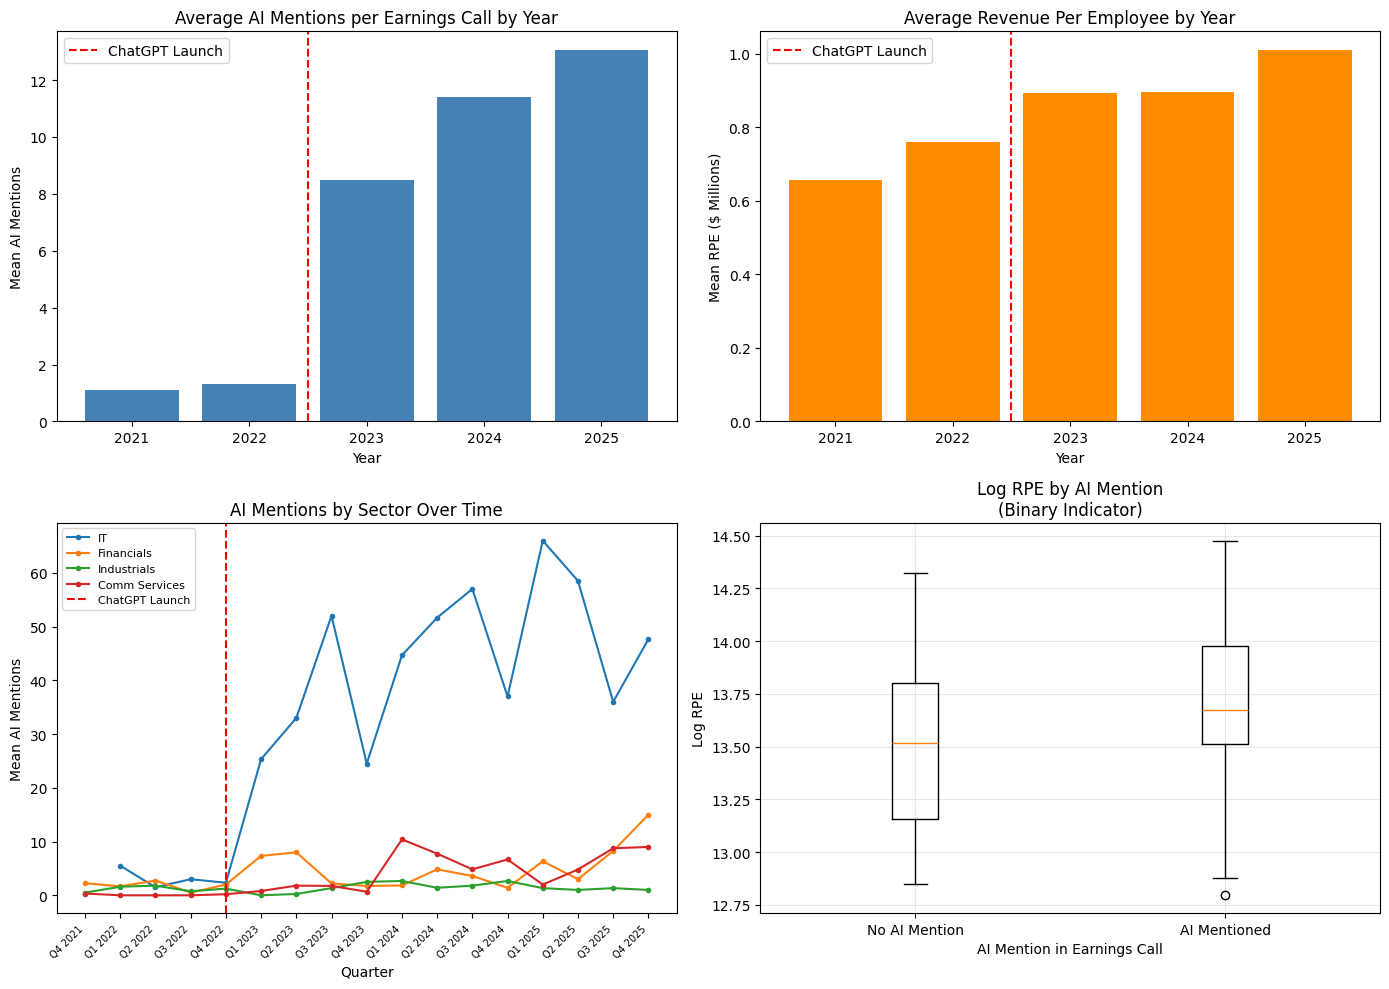

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Average AI mentions by year
yearly_score = df_filtered.groupby("year")["total_ai_mentions"].mean().reset_index()
axes[0,0].bar(yearly_score["year"], yearly_score["total_ai_mentions"], color="steelblue")
axes[0,0].axvline(x=2022.5, color="red", linestyle="--", label="ChatGPT Launch")
axes[0,0].set_title("Average AI Mentions per Earnings Call by Year")
axes[0,0].set_xlabel("Year")
axes[0,0].set_ylabel("Mean AI Mentions")
axes[0,0].legend()

# Chart 2: Average RPE by year
yearly_rpe = df_filtered.groupby("year")["Revenue per Employee"].mean().reset_index()
axes[0,1].bar(yearly_rpe["year"], yearly_rpe["Revenue per Employee"] / 1_000_000, color="darkorange")
axes[0,1].axvline(x=2022.5, color="red", linestyle="--", label="ChatGPT Launch")
axes[0,1].set_title("Average Revenue Per Employee by Year")
axes[0,1].set_xlabel("Year")
axes[0,1].set_ylabel("Mean RPE ($ Millions)")
axes[0,1].legend()

# Chart 3: AI mentions by sector over time by quarter
df_filtered["quarter_year"] = df_filtered["quarter"] + " " + df_filtered["year"].astype(str)

quarter_order = []
for year in sorted(df_filtered["year"].unique()):
    for q in ["Q1", "Q2", "Q3", "Q4"]:
        qy = f"{q} {year}"
        if qy in df_filtered["quarter_year"].values:
            quarter_order.append(qy)

sector_quarterly = df_filtered.groupby(["sector", "quarter_year"])["total_ai_mentions"].mean().reset_index()

for sector in df_filtered["sector"].unique():
    data = sector_quarterly[sector_quarterly["sector"] == sector]
    data = data.set_index("quarter_year").reindex(quarter_order).reset_index()
    axes[1,0].plot(range(len(data)), data["total_ai_mentions"], marker="o", label=sector, markersize=3)

chatgpt_idx = quarter_order.index("Q4 2022")
axes[1,0].axvline(x=chatgpt_idx, color="red", linestyle="--", label="ChatGPT Launch")
axes[1,0].set_xticks(range(len(quarter_order)))
axes[1,0].set_xticklabels(quarter_order, rotation=45, ha='right', fontsize=7)
axes[1,0].set_title("AI Mentions by Sector Over Time")
axes[1,0].set_xlabel("Quarter")
axes[1,0].set_ylabel("Mean AI Mentions")
axes[1,0].legend(fontsize=8)

# Chart 4: Box plot - RPE by AI mention binary
ai_yes = df_filtered[df_filtered["ai_mention"] == 1]["log_rpe"]
ai_no = df_filtered[df_filtered["ai_mention"] == 0]["log_rpe"]

axes[1,1].boxplot([ai_no, ai_yes], labels=["No AI Mention", "AI Mentioned"])
axes[1,1].set_title("Log RPE by AI Mention\n(Binary Indicator)")
axes[1,1].set_xlabel("AI Mention in Earnings Call")
axes[1,1].set_ylabel("Log RPE")
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/DSO459/459 Earnings Calls Transcripts/visualizations.png", dpi=150, bbox_inches="tight")
plt.show()

Chart 5: Sector Coefficient Plot

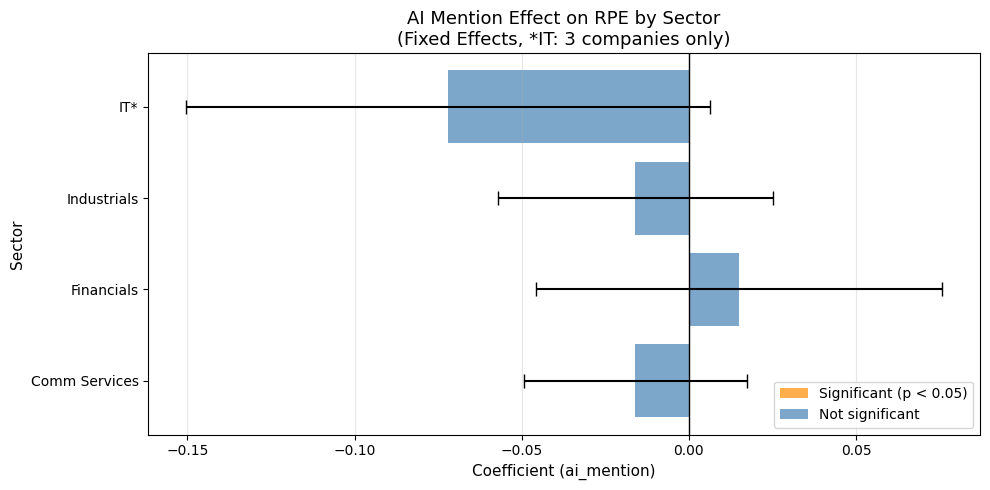

In [ ]:
sectors = ["Comm Services", "Financials", "Industrials", "IT*"]
coefs = [-0.016, 0.015, -0.016, -0.072]
std_errs = [0.017*1.96, 0.031*1.96, 0.021*1.96, 0.040*1.96]
pvals = [0.341, 0.633, 0.443, 0.075]

colors = []
for p in pvals:
    if p > 0.05:
        colors.append("steelblue")
    else:
        colors.append("darkorange")

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(sectors, coefs, xerr=std_errs, color=colors,
        capsize=5, alpha=0.7)
ax.axvline(x=0, color="black", linestyle="-", linewidth=1)
ax.set_title("AI Mention Effect on RPE by Sector\n(Fixed Effects, *IT: 3 companies only)", fontsize=13)
ax.set_xlabel("Coefficient (ai_mention)", fontsize=11)
ax.set_ylabel("Sector", fontsize=11)
ax.grid(True, alpha=0.3, axis='x')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='darkorange', alpha=0.7, label='Significant (p < 0.05)'),
    Patch(facecolor='steelblue', alpha=0.7, label='Not significant')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/DSO459/459 Earnings Calls Transcripts/sector_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

Chart 6: Interaction Model Coefficient plot

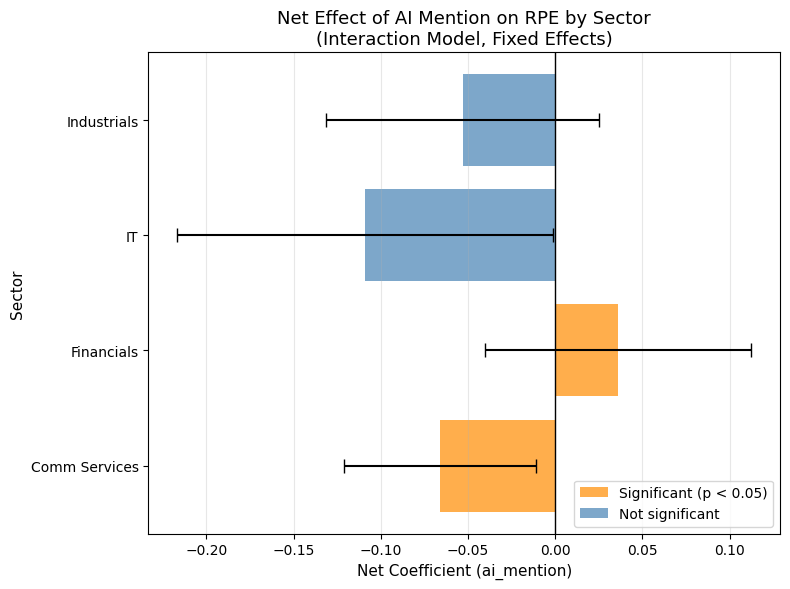

In [ ]:
# Extract coefficients from interaction model
# Base = Comm Services (alphabetically first)
# Net effects per sector
sectors = ["Comm Services", "Financials", "IT", "Industrials"]

# From interaction model results
base_coef = -0.066  # ai_mention base (Comm Services)
coefs = [
    base_coef,                    # Comm Services
    base_coef + 0.102,            # Financials: base + interaction
    base_coef + (-0.043),         # IT: base + interaction
    base_coef + 0.013             # Industrials: base + interaction
]
std_errs = [0.028*1.96, 0.039*1.96, 0.055*1.96, 0.040*1.96]
pvals = [0.020, 0.008, 0.431, 0.757]

colors = []
for p in pvals:
    if p > 0.05:
        colors.append("steelblue")
    else:
        colors.append("darkorange")

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(sectors, coefs, xerr=std_errs, color=colors,
        capsize=5, alpha=0.7)
ax.axvline(x=0, color="black", linestyle="-", linewidth=1)
ax.set_title("Net Effect of AI Mention on RPE by Sector\n(Interaction Model, Fixed Effects)", fontsize=13)
ax.set_xlabel("Net Coefficient (ai_mention)", fontsize=11)
ax.set_ylabel("Sector", fontsize=11)
ax.grid(True, alpha=0.3, axis='x')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='darkorange', alpha=0.7, label='Significant (p < 0.05)'),
    Patch(facecolor='steelblue', alpha=0.7, label='Not significant')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/DSO459/459 Earnings Calls Transcripts/interaction_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

Chart 7: DiD Plot

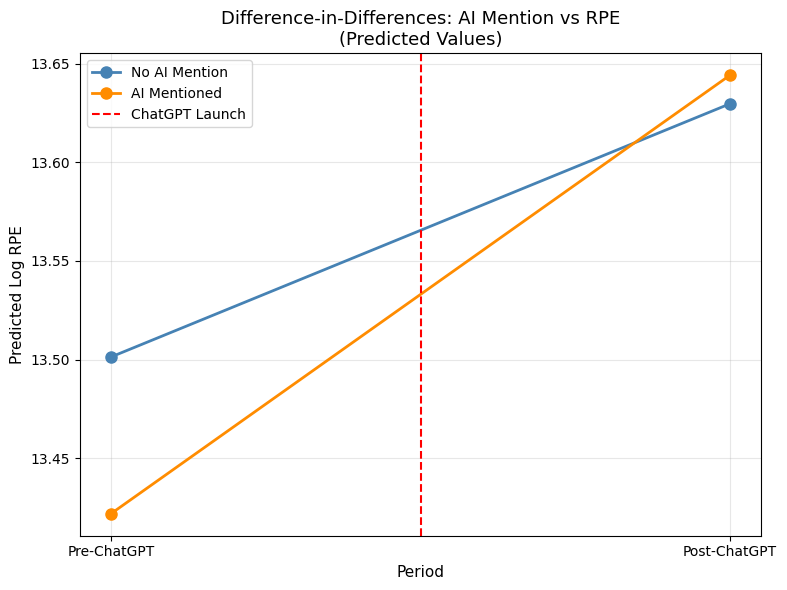

In [ ]:
# DiD visualization - show predictions by group over time
df_filtered['preds_did'] = model_did.predict(df_filtered)

# Group by post_chatgpt and ai_mention
did_trends = df_filtered.groupby(
    ["post_chatgpt", "ai_mention"]
)["preds_did"].mean().reset_index()

plt.figure(figsize=(8, 6))

# Plot each group
for ai_val, label, color in [(0, "No AI Mention", "steelblue"), (1, "AI Mentioned", "darkorange")]:
    data = did_trends[did_trends["ai_mention"] == ai_val]
    plt.plot(
        data["post_chatgpt"],
        data["preds_did"],
        marker="o",
        label=label,
        color=color,
        linewidth=2,
        markersize=8
    )

plt.axvline(x=0.5, color="red", linestyle="--", label="ChatGPT Launch")
plt.xticks([0, 1], ["Pre-ChatGPT", "Post-ChatGPT"])
plt.title("Difference-in-Differences: AI Mention vs RPE\n(Predicted Values)", fontsize=13)
plt.xlabel("Period", fontsize=11)
plt.ylabel("Predicted Log RPE", fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/DSO459/459 Earnings Calls Transcripts/did_plot.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
df_filtered[df_filtered["ticker"] == "JPM"][["quarter", "year", "total_ai_mentions", "ai_mention"]].sort_values(["year", "quarter"])

,quarter,year,total_ai_mentions,ai_mention
119,Q4,2021,4,1
120,Q1,2022,0,0
121,Q2,2022,1,1
122,Q3,2022,0,0
123,Q4,2022,0,0
124,Q2,2023,1,1
125,Q4,2023,7,1
126,Q1,2024,0,0
127,Q2,2024,1,1
128,Q3,2024,3,1


In [ ]:
df_filtered[df_filtered["ticker"].isin(["V", "MA"])][["ticker", "quarter", "year", "total_ai_mentions"]].sort_values(["ticker", "year", "quarter"])


,ticker,quarter,year,total_ai_mentions
146,MA,Q4,2021,0
147,MA,Q1,2022,6
148,MA,Q2,2022,7
149,MA,Q3,2022,0
150,MA,Q4,2022,5
151,MA,Q1,2023,22
152,MA,Q2,2023,3
153,MA,Q3,2023,2
154,MA,Q1,2024,9
155,MA,Q2,2024,22
